In [ ]:
# NYC Street Tree Health Analysis

## Research Question

What factors are associated with the health of NYC street trees?

## Motivation

New York City has hundreds of thousands of street trees that provide environmental benefits and contribute to the quality of urban life.
This project analyzes NYC street tree data to identify patterns in tree health across the city.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
url = "https://data.cityofnewyork.us/resource/uvpi-gqnh.json?$limit=100000"

df = pd.read_json(url)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (100000, 45)


,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council_district,census_tract,bin,bbl
0,180683,348711,2015-08-27,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,2015-09-03,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,2015-09-05,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,2015-09-05,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,2015-08-30,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


In [4]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns:
(100000, 45)

Column names:
['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam', 'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward', 'guards', 'sidewalk', 'user_type', 'problems', 'root_stone', 'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other', 'brch_light', 'brch_shoe', 'brch_other', 'address', 'zipcode', 'zip_city', 'cb_num', 'borocode', 'boroname', 'cncldist', 'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state', 'latitude', 'longitude', 'x_sp', 'y_sp', 'council_district', 'census_tract', 'bin', 'bbl']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tree_id           100000 non-null  int64         
 1   block_id          100000 non-null  int64         
 2   created_at        100000 non-null  datetime64[ns]
 3   tree_dbh          100000 non-null  int64         
 4   stump_diam        100000 non-null  int64         
 5   curb_loc          100000 non-null  object        
 6   status            100000 non-null  object        
 7   health            94824 non-null   object        
 8   spc_latin         94825 non-null   object        
 9   spc_common        94825 non-null   object        
 10  steward           94825 non-null   object        
 11  guards            94825 non-null   object        
 12  sidewalk          94825 non-null   object        
 13  user_type         100000 non-null  object        
 14  probl

In [6]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Missing values:
health              5176
spc_common          5175
steward             5175
spc_latin           5175
guards              5175
sidewalk            5175
problems            5175
bbl                 1253
bin                 1253
census_tract         815
council_district     815
created_at             0
stump_diam             0
status                 0
curb_loc               0
dtype: int64


In [7]:
df.describe()

,tree_id,block_id,created_at,tree_dbh,stump_diam,zipcode,cb_num,borocode,cncldist,st_assem,st_senate,boro_ct,latitude,longitude,x_sp,y_sp,council_district,census_tract,bin,bbl
count,100000.000000,100000.00000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,1.000000e+05,100000.000000,100000.000000,1.000000e+05,100000.000000,99185.000000,99185.000000,9.874700e+04,9.874700e+04
mean,233766.615360,289448.53787,2015-09-16 05:22:41.376000,11.246580,0.488790,10825.054290,316.003300,3.083390,27.328490,52.32161,21.395470,3.127723e+06,40.711261,-73.926950,1.004479e+06,198437.668431,27.403065,10909.881151,3.209907e+06,3.133721e+09
min,7.000000,100002.00000,2015-05-19 00:00:00,0.000000,0.000000,83.000000,101.000000,1.000000,1.000000,23.00000,10.000000,1.000201e+06,40.498466,-74.254385,9.135095e+05,120973.792200,1.000000,1.000000,1.000000e+06,0.000000e+00
25%,208733.750000,212588.00000,2015-09-07 00:00:00,5.000000,0.000000,10309.000000,210.000000,2.000000,14.000000,35.00000,14.000000,2.028800e+06,40.638179,-73.977241,9.905611e+05,171787.240450,15.000000,167.000000,2.073820e+06,2.050110e+09
50%,235821.500000,305825.00000,2015-09-18 00:00:00,10.000000,0.000000,11208.000000,314.000000,3.000000,26.000000,52.00000,22.000000,3.059300e+06,40.723671,-73.938414,1.001309e+06,202969.260300,26.000000,440.000000,3.217051e+06,3.067190e+09
75%,264700.250000,347894.00000,2015-09-27 00:00:00,16.000000,0.000000,11356.000000,411.000000,4.000000,40.000000,67.00000,27.000000,4.080301e+06,40.770801,-73.849481,1.025905e+06,220111.983425,40.000000,1162.000000,4.176083e+06,4.079190e+09
max,366359.000000,516315.00000,2015-10-23 00:00:00,425.000000,140.000000,11697.000000,503.000000,5.000000,51.000000,87.00000,36.000000,5.031902e+06,40.912807,-73.700488,1.067248e+06,271853.443500,51.000000,157903.000000,5.167824e+06,5.080490e+09
std,42534.354313,122337.54174,NaN,8.550456,3.509538,835.657511,125.824751,1.264441,15.176808,18.44760,7.479332,1.278458e+06,0.089466,0.115601,3.206396e+04,32594.709788,15.154165,31330.582535,1.296823e+06,1.274243e+09


In [8]:
columns_needed = [
    "tree_id",
    "tree_dbh",
    "status",
    "health",
    "spc_common",
    "boroname",
    "steward"
]

trees = df[columns_needed].copy()

print("Original dataset:", df.shape)
print("Working dataset:", trees.shape)

trees.head()

Original dataset: (100000, 45)
Working dataset: (100000, 7)


,tree_id,tree_dbh,status,health,spc_common,boroname,steward
0,180683,3,Alive,Fair,red maple,Queens,None
1,200540,21,Alive,Fair,pin oak,Queens,None
2,204026,3,Alive,Good,honeylocust,Brooklyn,1or2
3,204337,10,Alive,Good,honeylocust,Brooklyn,None
4,189565,21,Alive,Good,American linden,Brooklyn,None


In [9]:
text_columns = [
    "status",
    "health",
    "spc_common",
    "boroname",
    "steward"
]

for column in text_columns:
    trees[column] = trees[column].astype("string").str.strip()

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


In [10]:
print("Tree health categories:")
print(trees["health"].value_counts(dropna=False))

Tree health categories:
health
Good    72188
Fair    17245
Poor     5391
<NA>     5176
Name: count, dtype: Int64


In [11]:
print("Tree status categories:")
print(trees["status"].value_counts(dropna=False))

Tree status categories:
status
Alive    94825
Stump     2941
Dead      2234
Name: count, dtype: Int64


In [12]:
trees_clean = trees[
    (trees["status"] == "Alive") &
    (trees["health"].notna()) &
    (trees["boroname"].notna()) &
    (trees["tree_dbh"] > 0)
].copy()

print("Cleaned dataset:", trees_clean.shape)
print("Missing values:")
print(trees_clean.isnull().sum())

Cleaned dataset: (94811, 7)
Missing values:
tree_id       0
tree_dbh      0
status        0
health        0
spc_common    0
boroname      0
steward       0
dtype: int64


In [13]:
bins = [0, 6, 12, 24, float("inf")]
labels = ["Small", "Medium", "Large", "Very Large"]

trees_clean["size_category"] = pd.cut(
    trees_clean["tree_dbh"],
    bins=bins,
    labels=labels,
    right=True
)

print("Tree size categories:")
print(trees_clean["size_category"].value_counts())

Tree size categories:
size_category
Small         31203
Medium        28074
Large         27113
Very Large     8421
Name: count, dtype: int64


In [14]:
trees_clean["is_healthy"] = (
    trees_clean["health"] == "Good"
).astype(int)

print("Healthy tree indicator created.")
print(trees_clean["is_healthy"].value_counts())

Healthy tree indicator created.
is_healthy
1    72179
0    22632
Name: count, dtype: int64


In [15]:
print("Tree Diameter Statistics:")
print(trees_clean["tree_dbh"].describe())

print("\nMedian tree diameter:", trees_clean["tree_dbh"].median())
print("Mean tree diameter:", trees_clean["tree_dbh"].mean())

Tree Diameter Statistics:
count    94811.000000
mean        11.732847
std          8.464038
min          1.000000
25%          5.000000
50%         10.000000
75%         16.000000
max        425.000000
Name: tree_dbh, dtype: float64

Median tree diameter: 10.0
Mean tree diameter: 11.732847454409299


In [16]:
borough_counts = trees_clean["boroname"].value_counts()

print("Number of trees by borough:")
print(borough_counts)

Number of trees by borough:
boroname
Queens           30735
Brooklyn         25535
Manhattan        16805
Bronx            10899
Staten Island    10837
Name: count, dtype: Int64


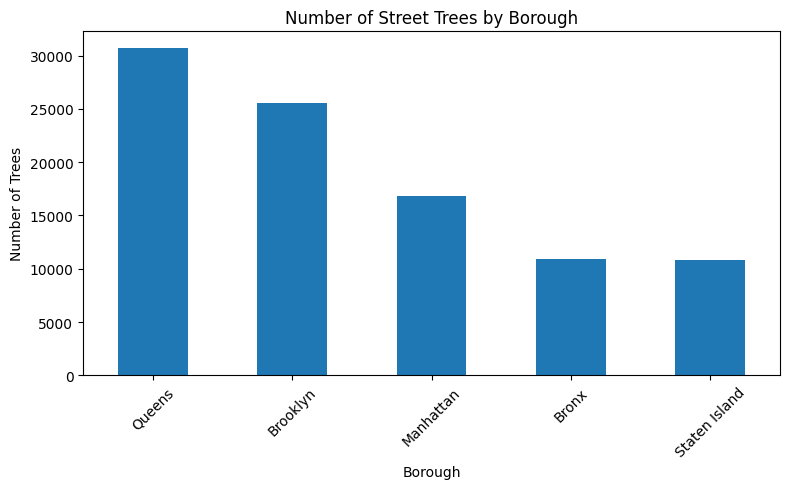

In [17]:
plt.figure(figsize=(8, 5))

borough_counts.plot(kind="bar")

plt.title("Number of Street Trees by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
health_counts = trees_clean["health"].value_counts()

print("Tree health distribution:")
print(health_counts)

Tree health distribution:
health
Good    72179
Fair    17243
Poor     5389
Name: count, dtype: Int64


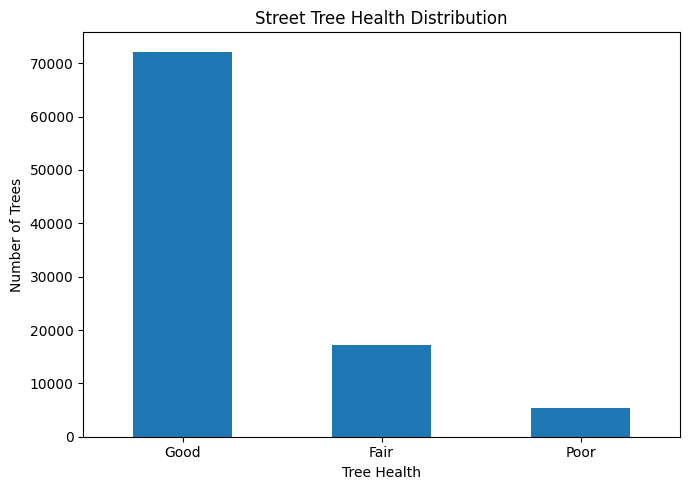

In [19]:
plt.figure(figsize=(7, 5))

health_counts.plot(kind="bar")

plt.title("Street Tree Health Distribution")
plt.xlabel("Tree Health")
plt.ylabel("Number of Trees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
health_by_borough = pd.crosstab(
    trees_clean["boroname"],
    trees_clean["health"],
    normalize="index"
) * 100

print("Tree health percentage by borough:")
print(health_by_borough.round(2))

Tree health percentage by borough:
health          Fair   Good  Poor
boroname                         
Bronx          15.87  79.58  4.55
Brooklyn       16.30  78.49  5.21
Manhattan      19.30  73.07  7.63
Queens         19.55  74.46  5.99
Staten Island  19.36  76.58  4.06


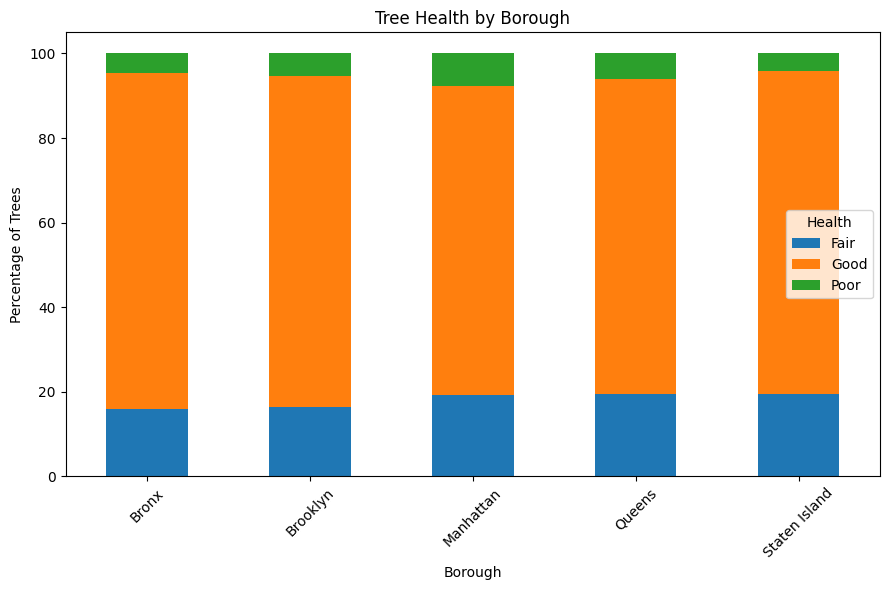

In [21]:
health_by_borough.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Tree Health by Borough")
plt.xlabel("Borough")
plt.ylabel("Percentage of Trees")
plt.legend(title="Health")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
diameter_by_health = trees_clean.groupby("health", observed=True)["tree_dbh"].median()

print("Median tree diameter by health:")
print(diameter_by_health)

Median tree diameter by health:
health
Fair    10.0
Good    10.0
Poor     7.0
Name: tree_dbh, dtype: float64


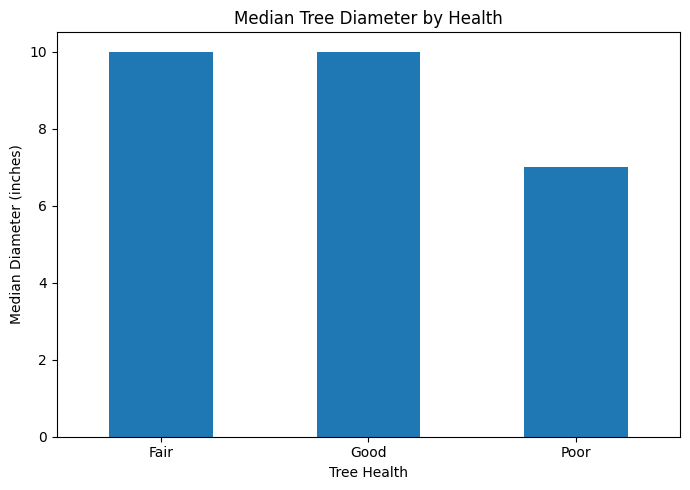

In [23]:
plt.figure(figsize=(7, 5))

diameter_by_health.plot(kind="bar")

plt.title("Median Tree Diameter by Health")
plt.xlabel("Tree Health")
plt.ylabel("Median Diameter (inches)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
health_borough_counts = pd.crosstab(
    trees_clean["boroname"],
    trees_clean["health"]
)

print("Tree health counts by borough:")
print(health_borough_counts)

Tree health counts by borough:
health         Fair   Good  Poor
boroname                        
Bronx          1730   8673   496
Brooklyn       4162  20042  1331
Manhattan      3244  12279  1282
Queens         6009  22886  1840
Staten Island  2098   8299   440


In [25]:
chi2, p_value, dof, expected = chi2_contingency(health_borough_counts)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: There is a statistically significant association between borough and tree health.")
else:
    print("Result: There is not a statistically significant association between borough and tree health.")

Chi-square statistic: 402.8100412031381
p-value: 4.6930526182198295e-82
Degrees of freedom: 8
Result: There is a statistically significant association between borough and tree health.


In [26]:
health_percentages = (
    trees_clean["health"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Overall tree health percentages:")
print(health_percentages)

Overall tree health percentages:
health
Good    76.13
Fair    18.19
Poor     5.68
Name: proportion, dtype: Float64


In [27]:
good_by_borough = (
    trees_clean.groupby("boroname")["is_healthy"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("Percentage of healthy trees by borough:")
print(good_by_borough)

Percentage of healthy trees by borough:
boroname
Bronx            79.58
Brooklyn         78.49
Staten Island    76.58
Queens           74.46
Manhattan        73.07
Name: is_healthy, dtype: float64


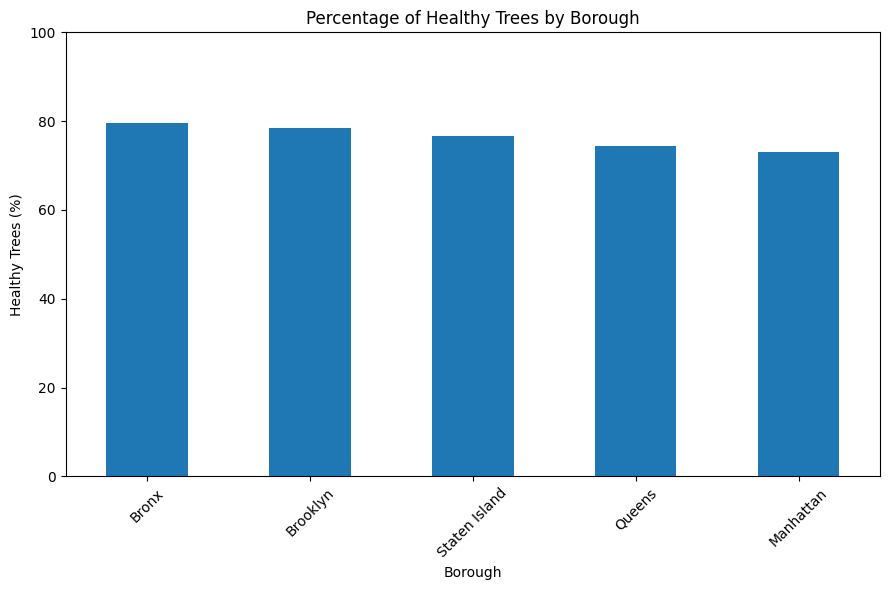

In [28]:
plt.figure(figsize=(9, 6))

good_by_borough.plot(kind="bar")

plt.title("Percentage of Healthy Trees by Borough")
plt.xlabel("Borough")
plt.ylabel("Healthy Trees (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
print("Final dataset size:", trees_clean.shape)

print("\nColumns in final dataset:")
print(trees_clean.columns.tolist())

print("\nHealth counts:")
print(trees_clean["health"].value_counts())

print("\nBorough counts:")
print(trees_clean["boroname"].value_counts())

Final dataset size: (94811, 9)

Columns in final dataset:
['tree_id', 'tree_dbh', 'status', 'health', 'spc_common', 'boroname', 'steward', 'size_category', 'is_healthy']

Health counts:
health
Good    72179
Fair    17243
Poor     5389
Name: count, dtype: Int64

Borough counts:
boroname
Queens           30735
Brooklyn         25535
Manhattan        16805
Bronx            10899
Staten Island    10837
Name: count, dtype: Int64


In [ ]:
# Findings and Results

The analysis used 94,811 living street trees with complete information for tree health, borough, and tree diameter.

Overall, 76.13% of the trees were classified as Good health, 18.19% as Fair, and 5.68% as Poor. The Bronx had the highest percentage of healthy trees at 79.58%, while Manhattan had the lowest at 73.07%.

Tree health also differed across boroughs. Queens had the largest number of trees in the dataset, but having more trees did not mean having the highest percentage of healthy trees.

The median tree diameter was 10 inches for trees in Good and Fair health and 7 inches for trees in Poor health. This suggests that poor-health trees tended to be smaller in this dataset, although this relationship does not establish that tree size causes differences in health.

In [ ]:
# Statistical Analysis

A chi-square test of independence was used to examine whether borough and tree health were statistically associated.

The test produced a chi-square statistic of 402.81 with 8 degrees of freedom and a p-value of approximately 4.69 × 10⁻⁸². Because the p-value is much smaller than 0.05, the null hypothesis was rejected.

This indicates that there is a statistically significant association between borough and tree health in this dataset. However, the test shows an association rather than causation.

In [ ]:
# Conclusion

The analysis found differences in street tree health across NYC boroughs. The Bronx had the highest percentage of healthy trees, while Manhattan had the lowest. The chi-square test also showed a statistically significant association between borough and tree health.

The analysis suggests that geographic differences may be useful when examining patterns in urban tree health. Tree diameter also showed a difference between health categories, with poor-health trees having a lower median diameter.

Overall, borough appears to be an important variable associated with street tree health in this dataset. These findings could help provide a starting point for understanding where differences in urban tree health may exist.

### Limitations

This analysis uses a sample of 100,000 records from the 2015 NYC Street Tree Census, rather than the complete dataset. The data are also from 2015, and statistical association does not mean that borough or tree size directly causes differences in tree health.